# Projeto Avaliativo — Machine Learning e Visão Computacional

## Previsão de Risco de Crédito

O objetivo deste projeto é desenvolver um pipeline preditivo capaz de identificar
clientes com risco de inadimplência.

A variável alvo utilizada será `loan_status`, onde:

- `0` = cliente sem inadimplência
- `1` = cliente inadimplente

O projeto será dividido em etapas de análise exploratória, tratamento de dados,
engenharia de atributos, preparação dos dados, treinamento dos modelos KNN e
Árvore de Decisão e avaliação dos resultados.

# 1. Preparação do Ambiente

## 1.1 Importação das Bibliotecas

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 1.2 Definição do Diretório do Projeto

In [34]:
os.chdir(r"C:\Users\Alisson\Desktop\Alisson\sctec\Projeto-risco-credito")

## 1.3 Carregamento da Base de Dados

In [35]:
df = pd.read_csv("data/credit_risk_dataset.csv")

df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# 2. Análise Exploratória de Dados (EDA)

Nesta etapa serão analisadas as dimensões da base, os tipos das variáveis, estatísticas descritivas, valores ausentes, distribuição da variável alvo e possíveis outliers.

## 2.1 Dimensões da Base

In [36]:
print("Linhas:", df.shape[0])
print("Colunas:", df.shape[1])

Linhas: 32581
Colunas: 12


## 2.2 Tipos de Dados e Valores Não Nulos

In [37]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


## 2.3 Estatísticas Descritivas

In [38]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


## 2.4 Análise de Valores Ausentes

Nesta etapa serão identificadas as colunas que possuem valores nulos e a quantidade de registros ausentes em cada uma delas.

A análise dos valores ausentes é importante para definir posteriormente a estratégia de imputação mais adequada, utilizando média ou mediana conforme a distribuição dos dados e a presença de outliers.

In [39]:
valores_nulos = df.isnull().sum()

valores_nulos[valores_nulos > 0]

person_emp_length     895
loan_int_rate        3116
dtype: int64

In [40]:
percentual_nulos = (df.isnull().sum() / len(df)) * 100

percentual_nulos[percentual_nulos > 0]

person_emp_length    2.747000
loan_int_rate        9.563856
dtype: float64

### Análise dos Valores Ausentes

Foram identificados valores ausentes em duas variáveis:

- `person_emp_length`: 895 valores ausentes, aproximadamente 2,75% da base.
- `loan_int_rate`: 3.116 valores ausentes, aproximadamente 9,56% da base.

Esses valores serão analisados posteriormente para definir a técnica de imputação mais adequada, considerando a distribuição dos dados e a influência de possíveis outliers.

## 2.5 Distribuição da Variável Alvo

A variável alvo do projeto é `loan_status`, onde:

- `0` representa clientes adimplentes.
- `1` representa clientes inadimplentes.

Nesta etapa será analisada a proporção entre as classes para verificar a existência de desbalanceamento na base.

In [41]:
contagem_classes = df["loan_status"].value_counts()
percentual_classes = df["loan_status"].value_counts(normalize=True) * 100

print("Quantidade por classe:")
display(contagem_classes)

print("\nPercentual por classe:")
display(percentual_classes)

Quantidade por classe:


loan_status
0    25473
1     7108
Name: count, dtype: int64


Percentual por classe:


loan_status
0    78.183604
1    21.816396
Name: proportion, dtype: float64

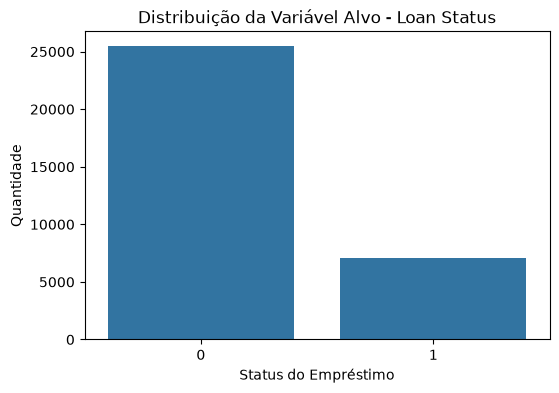

In [42]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="loan_status")

plt.title("Distribuição da Variável Alvo - Loan Status")
plt.xlabel("Status do Empréstimo")
plt.ylabel("Quantidade")

plt.show()

### Análise da Variável Alvo

A variável `loan_status` apresenta desbalanceamento entre as classes.

A classe `0`, referente aos clientes adimplentes, possui 25.473 registros e representa aproximadamente 78,18% da base.

A classe `1`, referente aos clientes inadimplentes, possui 7.108 registros e representa aproximadamente 21,82% da base.

Essa diferença evidencia o desbalanceamento da variável alvo. Na etapa de preparação dos dados, será aplicada uma técnica de balanceamento apenas sobre o conjunto de treino, evitando vazamento de dados para o conjunto de teste.

## 2.6 Análise de Outliers

Nesta etapa serão analisados possíveis valores discrepantes nas variáveis numéricas.

A identificação de outliers é especialmente importante porque o modelo KNN é sensível a valores extremos, já que utiliza medidas de distância entre os registros. Já a Árvore de Decisão tende a ser mais robusta a esse tipo de situação.

Por isso, os valores discrepantes não serão removidos automaticamente. Primeiro será avaliado se representam observações plausíveis ou inconsistências nos dados.

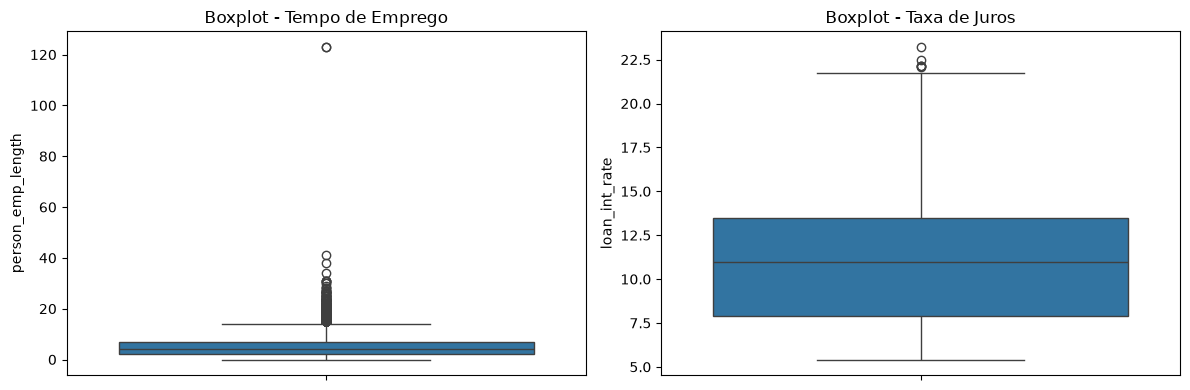

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(y=df["person_emp_length"], ax=axes[0])
axes[0].set_title("Boxplot - Tempo de Emprego")

sns.boxplot(y=df["loan_int_rate"], ax=axes[1])
axes[1].set_title("Boxplot - Taxa de Juros")

plt.tight_layout()
plt.show()

In [44]:
df.sort_values("person_emp_length", ascending=False)[
    ["person_age", "person_emp_length"]
].head(15)

,person_age,person_emp_length
210,21,123.0
0,22,123.0
32355,78,41.0
32515,53,38.0
32428,58,34.0
31866,47,31.0
30914,48,31.0
31867,46,31.0
32263,46,31.0
32539,61,30.0


### Análise dos Outliers

A variável `person_emp_length` apresentou diversos valores acima do limite superior do boxplot.

Ao analisar os maiores registros, foram encontrados dois casos em que o tempo de emprego é igual a 123 anos para clientes de 21 e 22 anos. Esses valores são logicamente impossíveis e indicam inconsistência nos dados.

Por outro lado, outros valores elevados de tempo de emprego, como 30, 31, 38 e 41 anos, podem ser plausíveis dependendo da idade do cliente e, por isso, não serão removidos automaticamente.

Na variável `loan_int_rate`, foram observados alguns valores acima do limite superior do boxplot, porém eles permanecem dentro de uma faixa possível para taxas de juros. Portanto, esses registros serão mantidos.

As inconsistências identificadas em `person_emp_length` serão tratadas na etapa de limpeza dos dados.

## 2.7 Análise de Correlação

Nesta etapa será analisada a correlação entre as variáveis numéricas da base.

A matriz de correlação ajuda a identificar relações lineares entre os atributos e a variável alvo, além de possíveis relações fortes entre variáveis preditoras.

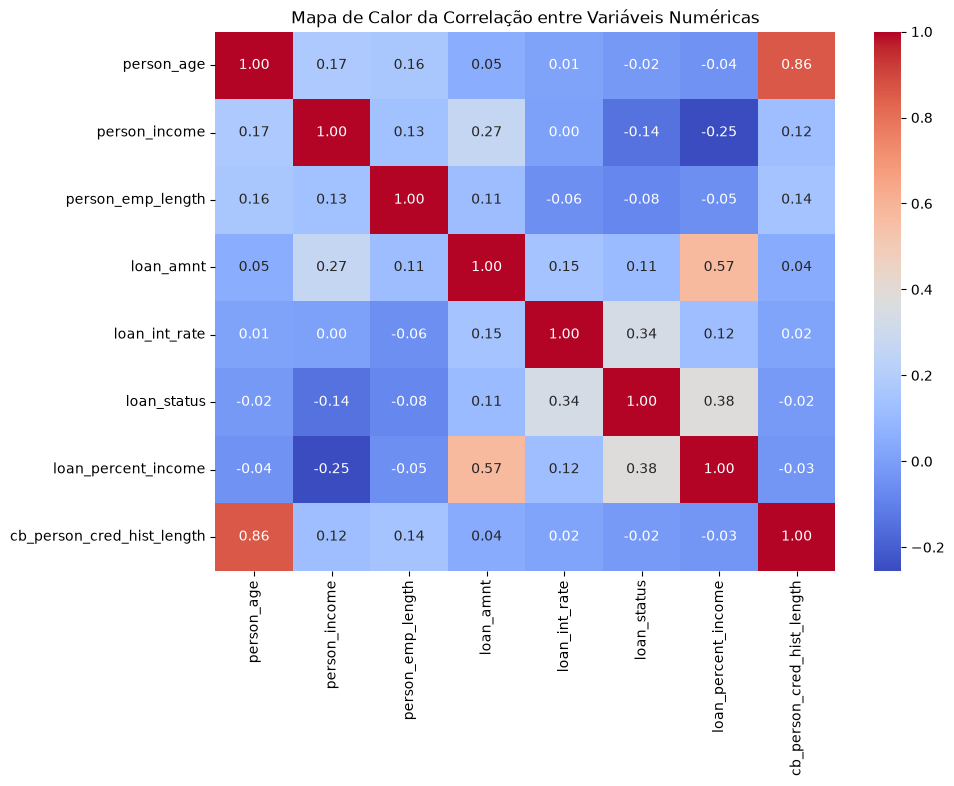

In [45]:
colunas_numericas = df.select_dtypes(include=["int64", "float64"])

correlacao = colunas_numericas.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlacao,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Mapa de Calor da Correlação entre Variáveis Numéricas")

plt.show()

# 3. Tratamento e Limpeza dos Dados

Nesta etapa serão tratados registros duplicados, valores inconsistentes, dados ausentes e possíveis outliers identificados durante a análise exploratória.

As decisões de tratamento serão realizadas buscando preservar a maior quantidade possível de informações válidas da base.

## 3.1 Identificação e Remoção de Registros Duplicados

Registros duplicados podem introduzir redundância na base e influenciar indevidamente o treinamento dos modelos.

Por isso, será verificada a existência de linhas completamente duplicadas antes da modelagem.

In [46]:
duplicados = df.duplicated().sum()

print("Quantidade de registros duplicados:", duplicados)

Quantidade de registros duplicados: 165


### Análise dos Registros Duplicados

Foram identificados 165 registros completamente duplicados na base de dados.

Como essas linhas representam repetições exatas de registros já existentes, elas serão removidas para evitar redundância e impedir que determinadas observações tenham peso indevido durante o treinamento dos modelos.

In [47]:
df = df.drop_duplicates()

print("Quantidade de registros após remoção:", len(df))
print("Duplicados restantes:", df.duplicated().sum())

Quantidade de registros após remoção: 32416
Duplicados restantes: 0


## 3.2 Tratamento de Valores Inconsistentes

Durante a análise exploratória foram identificados registros em que o tempo de emprego (`person_emp_length`) é superior à idade do cliente (`person_age`).

Esse tipo de valor representa uma inconsistência lógica nos dados e não apenas um outlier estatístico.

Por isso, esses registros serão identificados e os valores inconsistentes de tempo de emprego serão convertidos para `NaN`, permitindo que sejam tratados posteriormente junto com os demais valores ausentes.

In [48]:
inconsistentes_emprego = df[
    df["person_emp_length"] > df["person_age"]
][["person_age", "person_emp_length"]]

inconsistentes_emprego

,person_age,person_emp_length
0,22,123.0
210,21,123.0


In [49]:
print(
    "Quantidade de registros inconsistentes:",
    len(inconsistentes_emprego)
)

Quantidade de registros inconsistentes: 2


### Tratamento dos Valores Inconsistentes

Foram identificados 2 registros em que o tempo de emprego é superior à idade do cliente.

Como esses valores são logicamente impossíveis, eles serão convertidos para `NaN` em vez de remover as linhas completas. Dessa forma, preservamos as demais informações válidas desses registros e tratamos apenas a variável inconsistente.

In [50]:
df.loc[
    df["person_emp_length"] > df["person_age"],
    "person_emp_length"
] = np.nan

In [51]:
print(
    "Registro inconsistentes restantes:", (df["person_emp_length"] > df["person_age"]).sum()
)

Registro inconsistentes restantes: 0


## 3.3 Tratamento de Valores Nulos

Após o tratamento das inconsistências, serão analisados novamente os valores ausentes da base.

A estratégia de imputação será escolhida de acordo com a distribuição das variáveis:

- A média pode ser utilizada quando os dados apresentam distribuição mais equilibrada e sem forte influência de outliers.
- A mediana é mais indicada quando existem valores extremos, pois é menos sensível a outliers.

### Estratégia de Imputação

Para a variável `person_emp_length`, será utilizada a mediana, pois a análise exploratória identificou valores extremos e uma distribuição mais sensível a outliers. A mediana é menos afetada por esses valores.

Para a variável `loan_int_rate`, será utilizada a média, pois os valores de média e mediana são muito próximos, indicando uma distribuição relativamente equilibrada.

In [52]:
mediana_emprego = df["person_emp_length"].median()
media_juros = df["loan_int_rate"].mean()

df["person_emp_length"] = df["person_emp_length"].fillna(mediana_emprego)
df["loan_int_rate"] = df["loan_int_rate"].fillna(media_juros)

In [53]:
print("Valore nulos restantes")
display(df[["person_emp_length", "loan_int_rate"]].isnull().sum())

Valore nulos restantes


person_emp_length    0
loan_int_rate        0
dtype: int64

## 3.4 Tratamento de Outliers

Após o tratamento dos valores inconsistentes e ausentes, será realizada uma nova análise das variáveis numéricas para identificar valores extremos que ainda possam afetar os modelos.

Os outliers não serão removidos automaticamente. Cada caso será avaliado considerando se o valor é plausível dentro do contexto do problema.

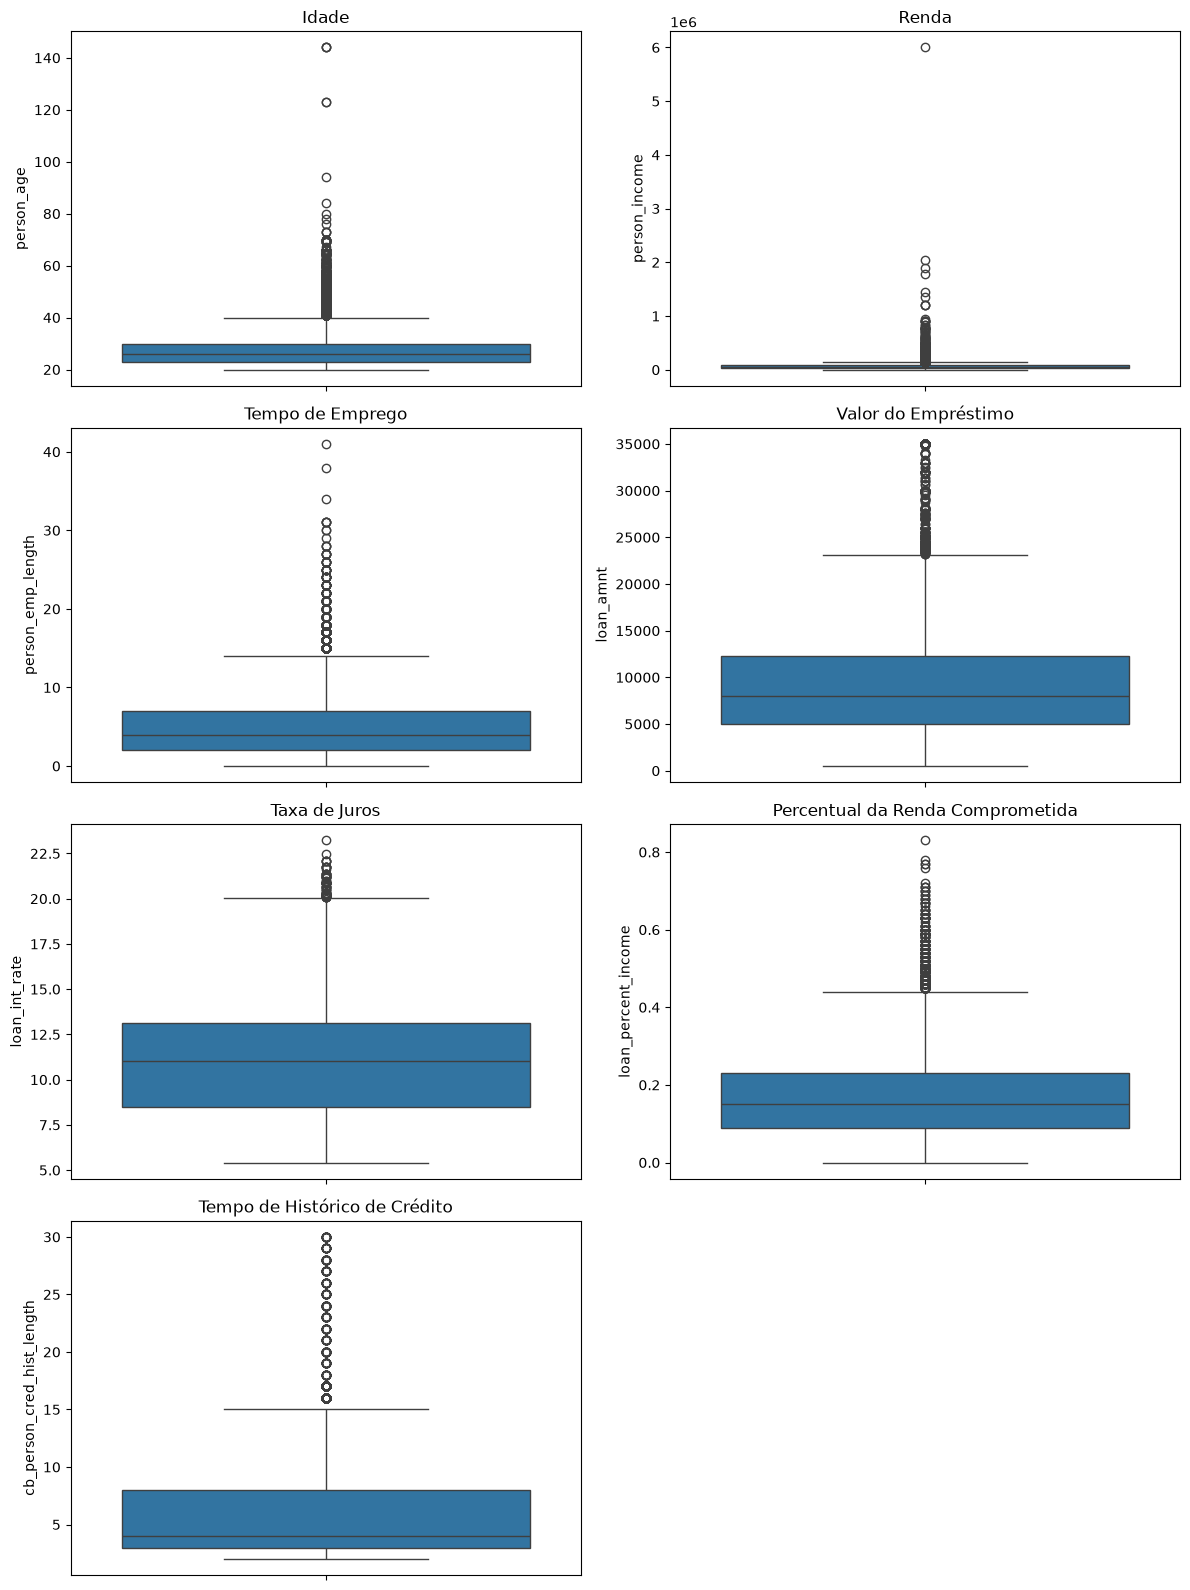

In [58]:
nomes_graficos = {
    "person_age": "Idade",
    "person_income": "Renda",
    "person_emp_length": "Tempo de Emprego",
    "loan_amnt": "Valor do Empréstimo",
    "loan_int_rate": "Taxa de Juros",
    "loan_percent_income": "Percentual da Renda Comprometida",
    "cb_person_cred_hist_length": "Tempo de Histórico de Crédito"
}

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.flatten()

for i, coluna in enumerate(colunas_numericas):
    sns.boxplot(y=df[coluna], ax=axes[i])
    axes[i].set_title(nomes_graficos[coluna])

fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

In [57]:
df[colunas_numericas].agg(["min", "median", "mean", "max"]).T

,min,median,mean,max
person_age,20.00,26.000000,27.747008,144.00
person_income,4000.00,55000.000000,66091.640826,6000000.00
person_emp_length,0.00,4.000000,4.761538,41.00
loan_amnt,500.00,8000.000000,9593.845632,35000.00
loan_int_rate,5.42,11.017265,11.017265,23.22
loan_percent_income,0.00,0.150000,0.170250,0.83
cb_person_cred_hist_length,2.00,4.000000,5.811297,30.00


### Investigação de Valores Extremos

Os boxplots indicaram valores extremos principalmente nas variáveis `person_age` e `person_income`.

Antes de qualquer remoção ou alteração, esses registros serão analisados individualmente para verificar se representam valores plausíveis ou inconsistências nos dados.

In [ ]:
print("maiores idades:")
display(
    df.sort_values("person_age", ascending=False)[
        ["person_age", "person_income", "person_emp_length"]
    ].head(10)
)

maiores idades:


,person_age,person_income,person_emp_length
32297,144,6000000,12.0
81,144,250000,4.0
183,144,200000,4.0
747,123,78000,7.0
575,123,80004,2.0
32416,94,24000,1.0
32506,84,94800,2.0
32422,80,64000,7.0
32355,78,48000,41.0
32534,76,75000,23.0


### Tratamento de Idades Inconsistentes

A investigação dos valores extremos revelou registros com idades de 123 e 144 anos.

Esses valores foram considerados inconsistentes para o contexto da base. Como representam uma quantidade muito pequena de registros em relação ao total da amostra, optou-se pela remoção completa dessas linhas, evitando a criação artificial de valores de idade por imputação.

Os demais clientes com idades elevadas, como 80, 84 e 94 anos, foram mantidos por representarem valores plausíveis.

In [61]:
idades_inconsistentes = df[df["person_age"] > 100]

print("Registros com idade superior a 100 anos:")
display(idades_inconsistentes)

print("Quantidade:", len(idades_inconsistentes))

Registros com idade superior a 100 anos:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.570000,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.860000,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.250000,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,11.017265,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.730000,0,0.00,N,25


Quantidade: 5


In [62]:
df = df[df["person_age"] <= 100].copy()

print("Quantidade de registros após o tratamento:", len(df))
print("Maior idade restante:", df["person_age"].max())

Quantidade de registros após o tratamento: 32411
Maior idade restante: 94


In [63]:
df.sort_values("person_income", ascending=False)[
    ["person_age", "person_income", "loan_amnt", "loan_status"]
].head(15)

,person_age,person_income,loan_amnt,loan_status
30049,42,2039784,8450,0
32546,60,1900000,1500,0
32497,63,1782000,12025,0
31924,44,1440000,6400,0
31922,47,1362000,6600,0
29120,40,1200000,10000,0
17833,32,1200000,12000,0
29119,36,1200000,10000,0
17834,34,948000,2000,0
29122,36,900000,6000,0
